# 07-2. 검색 결과를 뉴스 리포트로 정리하기

이 실습은 1단계 검색 그래프에 LLM 리포트 작성 노드를 추가하는 예제이다.

## 학습 목표

1. 검색 노드와 리포트 작성 노드를 순차적으로 연결한다.
2. Tavily 검색 결과를 LLM 프롬프트에 넣기 좋은 문자열로 변환한다.
3. LLM이 검색 결과를 바탕으로 뉴스 리포트를 생성하도록 구성한다.
4. `START → 검색 → 리포트작성 → END` 흐름을 이해한다.

## 전체 흐름

```text
START
  ↓
검색
  ↓
리포트작성
  ↓
END
```


## 0. 설치 패키지

이 실습은 LangGraph, OpenAI 모델, Tavily 검색 도구를 사용한다.  
처음 실행하는 환경에서는 아래 명령으로 필요한 패키지를 설치한다.

```bash
uv add langgraph langchain-openai langchain-tavily langchain-core python-dotenv grandalf
```

`.env` 파일에는 다음 값을 설정한다.

```text
OPENAI_API_KEY=발급받은_OpenAI_API_Key
TAVILY_API_KEY=발급받은_Tavily_API_Key
```


In [1]:
# 공통 환경 설정
# - .env 파일에서 API Key를 읽는다.
# - API Key가 없으면 실습 초반에 명확한 오류를 발생시킨다.
import os
from dotenv import load_dotenv

load_dotenv(override=True, dotenv_path="../.env")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

print("환경 변수 로드 완료")


환경 변수 로드 완료


In [ ]:
# LangGraph, LLM, Tavily 검색 도구를 불러온다.
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from IPython.display import Image, display

# LLM은 검색 결과를 자연어 리포트로 정리할 때 사용한다.
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)

# TavilySearch는 외부 웹 검색을 수행하는 도구이다.
tavily_tool = TavilySearch(max_results=5)


In [3]:
def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 검색 결과를 list[dict] 형태로 정리한다.

    TavilySearch의 반환값은 보통 {"results": [...]} 형태이다.
    실습에서는 이후 노드가 사용하기 쉽도록 검색 결과 리스트만 추출한다.
    """
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])

    if isinstance(raw_result, list):
        return raw_result

    return []


def format_search_results(results: list[dict]) -> str:
    """검색 결과를 LLM 프롬프트에 넣기 쉬운 문자열로 변환한다."""
    if not results:
        return "검색 결과가 없다."

    lines = []
    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(
            f"[{idx}] {title}\n"
            f"URL: {url}\n"
            f"내용: {content}"
        )

    return "\n\n".join(lines)


def show_graph(app):
    """그래프 구조를 시각화한다.

    Mermaid 이미지 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


## 1. State 정의

2단계에서는 검색 결과를 바탕으로 최종 리포트를 생성한다.  
따라서 `report` 필드를 추가한다.

| 필드 | 의미 |
|---|---|
| `topic` | 사용자가 알고 싶은 주제 |
| `search_query` | 실제 검색어 |
| `search_results` | Tavily 검색 결과 |
| `report` | LLM이 작성한 최종 리포트 |


In [4]:
class ReportState(TypedDict):
    # 사용자가 입력한 원래 주제이다.
    topic: str

    # Tavily 검색에 사용한 검색어이다.
    search_query: str

    # Tavily에서 받은 검색 결과 목록이다.
    search_results: list[dict]

    # LLM이 작성한 뉴스 리포트이다.
    report: str


## 2. 검색 노드 정의

1단계와 동일하게 Tavily 검색을 수행한다.  
검색 노드는 `search_query`와 `search_results`를 반환한다.


In [5]:
def search_node(state: ReportState) -> dict:
    """Tavily 검색을 수행하는 노드이다."""

    query = state["topic"]
    print(f"검색어: {query}")

    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    print(f"검색 결과 수: {len(results)}")

    return {
        "search_query": query,
        "search_results": results,
    }


## 3. 리포트 작성 체인 정의

LLM은 검색 결과 리스트를 직접 이해하기 어렵다.  
따라서 `format_search_results()` 함수로 검색 결과를 문자열로 바꾼 뒤 프롬프트에 넣는다.

날짜, 수치, 기관명은 검색 결과에 있는 경우에만 사용한다.  
제공되지 않은 정보는 추정하지 않는다.


In [6]:
report_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
너는 검색 결과를 바탕으로 짧은 뉴스 브리핑을 작성하는 AI이다.

작성 규칙:
1. 검색 결과에 있는 내용만 사용한다.
2. 날짜, 수치, 기관명은 원문에 있을 때만 사용한다.
3. 제공되지 않은 정보는 추정하지 않는다.
4. 한국어로 작성한다.
5. 제목, 핵심 요약, 주요 내용, 참고 링크 순서로 정리한다.
""".strip(),
    ),
    (
        "human",
        """
주제: {topic}

검색 결과:
{search_results}

위 검색 결과를 바탕으로 초보자도 이해할 수 있는 뉴스 리포트를 작성하라.
""".strip(),
    ),
])

# 프롬프트 → LLM → 문자열 출력 파서 순서로 실행되는 LangChain 체인이다.
report_chain = report_prompt | llm | StrOutputParser()


## 4. 리포트 작성 노드 정의

이 노드는 검색 결과를 받아 LLM 리포트를 생성한다.

입력으로 사용하는 State 값은 다음과 같다.

- `topic`
- `search_results`

반환하는 State 값은 다음과 같다.

- `report`


In [7]:
def report_node(state: ReportState) -> dict:
    """검색 결과를 바탕으로 뉴스 리포트를 작성하는 노드이다."""

    # 검색 결과를 프롬프트에 넣기 좋은 문자열로 변환한다.
    search_text = format_search_results(state["search_results"])

    # LLM 체인을 실행해 리포트를 생성한다.
    report = report_chain.invoke({
        "topic": state["topic"],
        "search_results": search_text,
    })

    return {"report": report}


## 5. 그래프 구성

검색 노드 다음에 리포트 작성 노드를 연결한다.

```text
START → 검색 → 리포트작성 → END
```


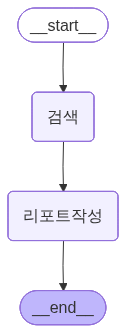

In [8]:
builder = StateGraph(ReportState)

# 두 개의 노드를 등록한다.
builder.add_node("검색", search_node)
builder.add_node("리포트작성", report_node)

# 순차 실행 흐름을 정의한다.
builder.add_edge(START, "검색")
builder.add_edge("검색", "리포트작성")
builder.add_edge("리포트작성", END)

app = builder.compile()

show_graph(app)


## 6. 그래프 실행

최종 결과에서 `report` 값을 확인한다.


In [9]:
result = app.invoke({
    "topic": "인공지능 최신 동향",
    "search_query": "",
    "search_results": [],
    "report": "",
})

print(result["report"])


검색어: 인공지능 최신 동향
검색 결과 수: 5
**제목:** 인공지능 최신 동향: 기술 발전과 산업 확장

**핵심 요약:** 인공지능(AI) 분야는 최근 급속한 발전을 이루고 있으며, 다양한 기술들이 실생활에 적용되고 있습니다. 특히, 다중 모달 모델, 저전력 경량 모델, 그리고 인공지능 일반 지능 개발이 주목받고 있습니다.

**주요 내용:**
최근 인공지능 산업은 생성형 AI의 출현 이후 빠르게 성장하고 있으며, 주요 기업들이 막대한 자본과 컴퓨팅 파워를 바탕으로 혁신적인 AI 모델을 연구 및 개발하고 있습니다. 현재 AI 기술의 주요 트렌드로는 다중 모달 모델의 등장, AI의 현실 이해 능력 강화, 온디바이스 AI, 저전력 및 경량 모델 개발, 그리고 인공지능 일반 지능과 대체 아키텍처의 발전이 있습니다.

또한, 데이터 마이닝, 영상 처리, 자연어 처리 등 다양한 분야에서 최신 기술들이 소개되고 있으며, GPT-4o와 같은 고급 모델도 주목받고 있습니다. 이러한 기술들은 AI의 실제 적용 범위를 넓히고 있으며, 기업들은 AI 기술을 통해 혁신적인 솔루션을 제공하고 있습니다.

**참고 링크:** [AI의 최신 기술 동향 총정리 - 투비통](https://tobetong.com/ai-part-2-ai%EC%9D%98-%ED%98%84%EC%9E%AC%EC%99%80-%EB%82%98%EC%95%84%EA%B0%88-%EA%B8%B8_ai%EC%9D%98-%EC%B5%9C%EC%8B%A0-%EA%B8%B0%EC%88%A0-%EB%8F%99%ED%96%A5-%EC%B4%9D%EC%A0%95%EB%A6%AC)  
[인공지능 분야 산업·기술 동향 및 이슈](https://ettrends.etri.re.kr/ettrends/212/0905212008/0905212008.html)  
[소프트웨어정책연구소 - 인공지능 기술개발 및 산업 동향](https://spri.kr/posts/view/15038?code=data_all&study_type=industry_

## 7. stream으로 단계별 실행 확인

`stream()`을 사용하면 검색 노드와 리포트 작성 노드가 각각 어떤 값을 반환하는지 확인할 수 있다.


In [11]:
for event in app.stream(
    {
        "topic": "생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기",
        "search_query": "",
        "search_results": [],
        "report": "",
    },
    stream_mode="updates",
):
    # print(event)
    # for update_data in event.values():
    #     print(update_data)
    for update_data in event.values():
        if "search_results" in update_data:
            for i, item in enumerate(update_data["search_results"], start=1):
                print(f"\n[{i}] {item.get('title')}")
                print(item.get("url"))
                print(item.get("content"))

검색어: 생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기
검색 결과 수: 5

[1] 슬래시 명령어 2개로 AI 트렌드 리서치 자동화하기 - 지피터스
https://www.gpters.org/nocode/post/automate-ai-trend-research-RQvsDXxztDI1htZ
목표. "URL만 주면 자동으로 내용 추출하고 마크다운으로 저장". 더 나아가서, 검색 키워드만 입력하면 관련 URL까지 찾아주면 좋겠다고 생각했어요.

[2] [PDF] 4차산업시대의생성형AI활용가이드.pdf
https://ecampus.pro.ac.kr/pluginfile.php/39/mod_ubboard/attachment/59496/4%EC%B0%A8%EC%82%B0%EC%97%85%EC%8B%9C%EB%8C%80%EC%9D%98%EC%83%9D%EC%84%B1%ED%98%95AI%ED%99%9C%EC%9A%A9%EA%B0%80%EC%9D%B4%EB%93%9C.pdf?forcedownload=1
Open AI 사이트 접속 및 Sign up 선택하기. 1. 이메일 주소(계정)생성 및 비밀번호 입력하기 ... 학습자료와 오픈소스 문제. 생성물의 저작물성25). - 오픈 소스 라이선스에

[3] May 13, 2026 [Searching for Academic Resources with AI ... - YouTube
https://www.youtube.com/watch?v=BghfRpw0tMw
2026년 5월 13일 [초심자를 위한 AI로 학술자료 검색하기] |  AI검색, 결과수집, 요약, 글쓰기, 탐지, 출판윤리
가톨릭대학교 성의교정도서관 아카이브
504 subscribers
3 likes
35 views
14 May 2026
안녕하세요! 리서치와 논문 작성이 막막한 초심자분들을 위해 준비했습니다.
가톨릭대학교 성의교정 도서관에서 진행된 교육 자료를 바탕으로, AI를 활용해 더 스마트하고 빠르게 학술 자료를 검색하고 관리하는 방법을 핵심만 쏙쏙 뽑아 정리해

## 정리

이 단계에서 확인한 내용은 다음과 같다.

1. 하나의 그래프 안에서 외부 검색과 LLM 생성을 순차적으로 연결할 수 있다.
2. 검색 결과는 LLM이 이해할 수 있도록 문자열로 정리해야 한다.
3. LangGraph의 각 노드는 자신이 담당하는 작업만 수행하고, 변경할 State 값만 반환한다.
4. 다음 단계에서는 검색 결과가 부족할 때 다시 검색하는 조건부 흐름을 추가한다.


---

## 핵심 정리

```python
# 1. Tavily Search 도구 초기화
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=5)

raw_result = tavily_tool.invoke({"query": "검색어"})
results = raw_result["results"]


# 2. 검색 결과를 LLM 입력용 문자열로 변환
def format_search_results(results: list[dict]) -> str:
    if not results:
        return "검색 결과가 없다."

    lines = []

    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(
            f"[{idx}] {title}\n"
            f"URL: {url}\n"
            f"내용: {content}"
        )

    return "\n\n".join(lines)


# 3. State 정의
from typing_extensions import TypedDict

class ReportState(TypedDict):
    topic: str
    search_query: str
    search_results: list[dict]
    report: str


# 4. 검색 노드
def search_node(state: ReportState) -> dict:
    query = state["topic"]

    raw_result = tavily_tool.invoke({"query": query})
    results = raw_result["results"]

    return {
        "search_query": query,
        "search_results": results,
    }


# 5. 리포트 작성 노드
def report_node(state: ReportState) -> dict:
    search_text = format_search_results(state["search_results"])

    report = report_chain.invoke({
        "topic": state["topic"],
        "search_results": search_text,
    })

    return {"report": report}


# 6. 그래프 구성
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ReportState)

builder.add_node("검색", search_node)
builder.add_node("리포트작성", report_node)

builder.add_edge(START, "검색")
builder.add_edge("검색", "리포트작성")
builder.add_edge("리포트작성", END)

app = builder.compile()
```

- 노드 설명 
   
| 노드 | 역할 |
|---|---|
| 검색 | 사용자의 주제를 검색어로 사용해 Tavily Search API로 웹 검색을 수행한다. |
| 리포트작성 | 검색 결과를 LLM 프롬프트에 넣기 좋은 문자열로 변환한 뒤 뉴스 리포트를 생성한다. |

- State 필드 설명    

| State 필드 | 의미 |
|---|---|
| `topic` | 사용자가 알고 싶은 원래 주제이다. |
| `search_query` | 실제 Tavily 검색에 사용한 검색어이다. |
| `search_results` | Tavily에서 반환한 검색 결과 목록이다. |
| `report` | LLM이 검색 결과를 바탕으로 작성한 최종 리포트이다. |

이 실습은 LangGraph에서 **외부 검색 API 호출 결과를 LLM 생성 노드로 전달하는 기본 파이프라인** 예제이다.

핵심 흐름은 다음과 같다.

```text
START
  ↓
검색
  ↓
리포트작성
  ↓
END
```

즉, 07-1이 “검색 도구를 노드로 연결하는 실습”이라면, 07-2는 여기에 **LLM 후처리 노드**를 추가해 검색 결과를 사람이 읽기 쉬운 리포트로 변환하는 실습이다.